# Bank Marketing Campaign Prediction Using Supervised Machine Learning

This notebook applies supervised machine learning techniques to predict whether a bank client will subscribe to a term deposit after a direct marketing campaign. The project uses the Bank Marketing dataset and compares three classification models to identify the most suitable model for practical decision-making.

## 1. Problem Definition

Banks often contact customers through marketing campaigns to promote financial products such as term deposits. However, contacting every customer can be expensive and time-consuming. Therefore, machine learning can be used to predict which customers are more likely to subscribe.

The main objective of this project is to build a supervised classification model that predicts whether a customer will subscribe to a term deposit based on demographic, financial, and campaign-related information.

This is a binary classification problem because the target variable has two possible outcomes:

- Yes: the customer subscribed to a term deposit
- No: the customer did not subscribe

The selected dataset is suitable for this assessment because it contains more than 15 variables and supports key machine learning stages such as data cleaning, categorical encoding, feature scaling, feature selection, model development, optimisation, and model comparison.

## 2. Dataset Source

The dataset used in this project is the Bank Marketing dataset from the UCI Machine Learning Repository.

Dataset link: https://archive.ics.uci.edu/dataset/222/bank+marketing

The dataset contains information collected from direct marketing campaigns of a Portuguese banking institution. The goal is to predict whether a client subscribed to a term deposit.

In [ ]:
# Core data handling libraries
import pandas as pd
import numpy as np

# Visualisation libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Warning control
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Load the Bank Marketing dataset
bank_raw_frame = pd.read_csv("bank-full.csv", sep=";")

# Create a working copy
bank_work_frame = bank_raw_frame.copy()

# Show first five records
bank_work_frame.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [ ]:
# Display number of rows and columns
row_count, column_count = bank_work_frame.shape

print("Number of rows:", row_count)
print("Number of columns:", column_count)

# Display column names
print("\nColumn names:")
print(bank_work_frame.columns.tolist())

Number of rows: 45211
Number of columns: 17

Column names:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


In [ ]:
# Check data types and non-null values
bank_work_frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [ ]:
# Summary statistics for numerical variables
bank_work_frame.describe().T

,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0


In [ ]:
# Check target variable distribution
target_summary_table = bank_work_frame["y"].value_counts().reset_index()
target_summary_table.columns = ["Subscription_Status", "Count"]

target_summary_table["Percentage"] = round(
    target_summary_table["Count"] / target_summary_table["Count"].sum() * 100, 2
)

target_summary_table

,Subscription_Status,Count,Percentage
0,no,39922,88.3
1,yes,5289,11.7


## Output analysis

The dataset contains 45,211 customer records and 17 variables, including one target variable (`y`) and sixteen predictor variables.

The numerical summary indicates considerable variation across several variables. For example, account balances range from -8,019 to 102,127, while campaign duration ranges from 0 to 4,918 seconds. These large ranges suggest the presence of potential outliers that may influence model performance.

The target variable is imbalanced. Approximately 88.3% of customers did not subscribe to a term deposit, while only 11.7% subscribed. This imbalance should be considered during model development and evaluation to avoid biased predictions.


## 3. Choice of Dependent and Independent Variables

The dependent variable selected for this project is `y`, which shows whether a customer subscribed to a term deposit. This variable is suitable because it directly represents the business outcome that the bank wants to predict.

The independent variables include customer-related, financial, and campaign-related features such as age, job, marital status, education, balance, housing loan, personal loan, contact type, campaign month, number of contacts, previous campaign outcome, and other related variables.

These features are useful because they may influence a customer's decision to subscribe. For example, a customer's balance, loan status, job type, and previous campaign outcome may affect their financial interest and response to marketing.

## 4. Selection of Supervised Learning Algorithms

Three supervised classification algorithms will be used in this project:

1. Logistic Regression  
Logistic Regression is selected as a baseline model because it is simple, interpretable, and suitable for binary classification problems.

2. Random Forest Classifier  
Random Forest is selected because it can handle non-linear relationships and identify important features. It is also useful when the dataset contains both numerical and categorical variables after encoding.

3. Gradient Boosting Classifier  
Gradient Boosting is selected because it builds models sequentially and can improve prediction performance by reducing previous errors. It is useful for comparing against both a simple linear model and a tree-based ensemble model.

Using these three algorithms allows a balanced comparison between a baseline model, a bagging-based ensemble model, and a boosting-based ensemble model.

###Step -2

# 5. Data Preparation


The following preprocessing activities will be performed:

- Checking for missing values
- Identifying duplicate records
- Examining categorical variables
- Encoding categorical variables into numerical format
- Scaling numerical features
- Splitting the dataset into training and testing subsets


In [ ]:
# Check missing values

missing_report = (
    bank_work_frame
    .isnull()
    .sum()
    .reset_index()
)

missing_report.columns = ["Feature", "Missing_Values"]

missing_report.sort_values(
    by="Missing_Values",
    ascending=False
)

,Feature,Missing_Values
0,age,0
1,job,0
2,marital,0
3,education,0
4,default,0
5,balance,0
6,housing,0
7,loan,0
8,contact,0
9,day,0


In [ ]:
# Check duplicate records

duplicate_total = bank_work_frame.duplicated().sum()

print("Duplicate records:", duplicate_total)

Duplicate records: 0


In [ ]:
# Check unknown values

for feature_name in bank_work_frame.select_dtypes(include="object").columns:

    unknown_total = (
        bank_work_frame[feature_name]
        .astype(str)
        .str.lower()
        .eq("unknown")
        .sum()
    )

    print(f"{feature_name}: {unknown_total}")

job: 288
marital: 0
education: 1857
default: 0
housing: 0
loan: 0
contact: 13020
month: 0
poutcome: 36959
y: 0


## Handling Missing and Unknown Values

The dataset does not contain traditional missing values represented as null values. However, several categorical variables contain the category "unknown", which indicates unavailable information.

Instead of removing these records, the "unknown" category will be retained because it may contain useful information and removing a large number of observations could reduce the dataset size unnecessarily.

In [ ]:
# Create encoded copy

encoded_frame = bank_work_frame.copy()

categorical_features = encoded_frame.select_dtypes(include="object").columns

encoded_frame = pd.get_dummies(
    encoded_frame,
    columns=categorical_features,
    drop_first=True
)

print("Encoded dataset shape:")
print(encoded_frame.shape)

Encoded dataset shape:
(45211, 43)


In [ ]:
# Separate predictors and target

predictor_matrix = encoded_frame.drop("y_yes", axis=1)

target_vector = encoded_frame["y_yes"]

print("Predictor shape:", predictor_matrix.shape)
print("Target shape:", target_vector.shape)

Predictor shape: (45211, 42)
Target shape: (45211,)


## Train-Test Split Strategy

The dataset was divided into training and testing subsets using an 80:20 ratio.


In [ ]:
from sklearn.model_selection import train_test_split

x_train_set, x_test_set, y_train_set, y_test_set = train_test_split(
    predictor_matrix,
    target_vector,
    test_size=0.20,
    random_state=42,
    stratify=target_vector
)

print("Training set:", x_train_set.shape)
print("Testing set:", x_test_set.shape)

print("\nTraining target distribution:")
print(y_train_set.value_counts(normalize=True) * 100)

print("\nTesting target distribution:")
print(y_test_set.value_counts(normalize=True) * 100)

Training set: (36168, 42)
Testing set: (9043, 42)

Training target distribution:
y_yes
False    88.301814
True     11.698186
Name: proportion, dtype: float64

Testing target distribution:
y_yes
False    88.300343
True     11.699657
Name: proportion, dtype: float64


## Feature Scaling

Feature scaling was applied using StandardScaler.

Scaling transforms numerical variables to a common scale with a mean of zero and a standard deviation of one. This helps algorithms such as Logistic Regression perform more effectively and prevents variables with larger numerical ranges from dominating the learning process.

Scaling was applied only to numerical variables, while encoded categorical variables remained unchanged.

In [ ]:
from sklearn.preprocessing import StandardScaler

scale_columns = [
    "age",
    "balance",
    "day",
    "duration",
    "campaign",
    "pdays",
    "previous"
]

scaler_object = StandardScaler()

x_train_set[scale_columns] = scaler_object.fit_transform(
    x_train_set[scale_columns]
)

x_test_set[scale_columns] = scaler_object.transform(
    x_test_set[scale_columns]
)

print("Scaling completed.")

Scaling completed.


In [ ]:
from sklearn.model_selection import StratifiedKFold

cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print(cv_strategy)

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


## Cross-Validation Strategy

A 5-fold Stratified Cross-Validation strategy will be used during model training and hyperparameter optimisation.

This approach divides the training data into five folds while preserving the class distribution in each fold. The process helps reduce overfitting and provides a more reliable estimate of model performance.

In [ ]:
from sklearn.model_selection import StratifiedKFold

cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print(cv_strategy)

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


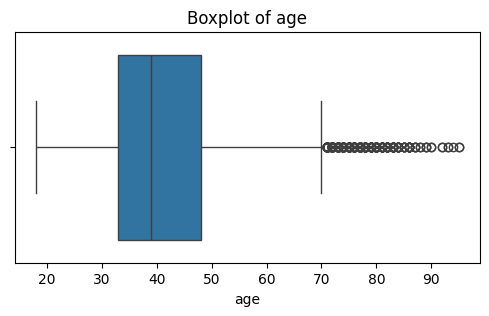

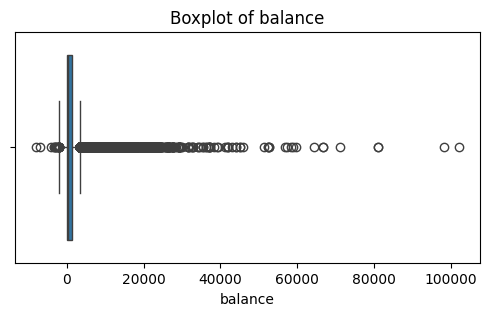

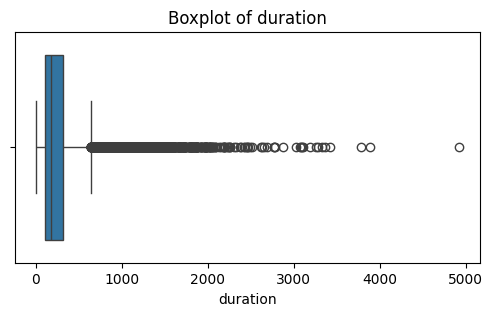

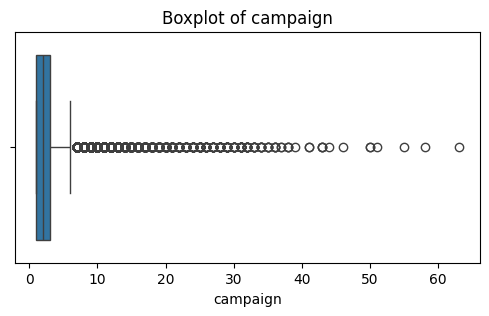

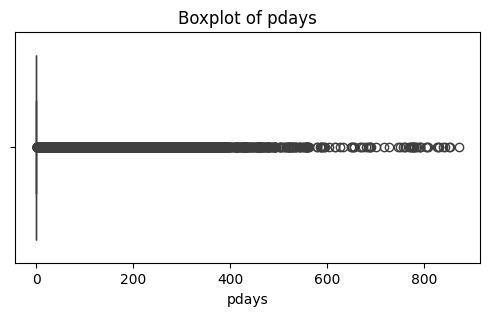

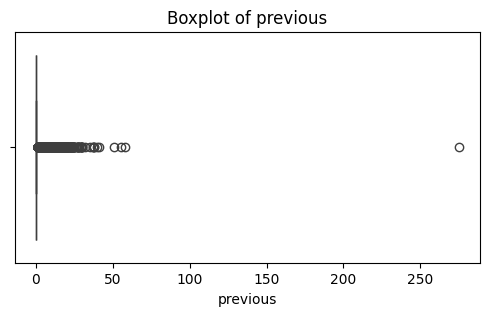

In [ ]:
numeric_review = [
    "age",
    "balance",
    "duration",
    "campaign",
    "pdays",
    "previous"
]

for metric_name in numeric_review:

    plt.figure(figsize=(6,3))

    sns.boxplot(
        x=bank_work_frame[metric_name]
    )

    plt.title(f"Boxplot of {metric_name}")

    plt.show()